In [0]:
# カレントディレクトリを変更
import os
os.chdir('../')

# 必要なライブラリをインストール
!pip install snowflake-snowpark-python==1.39.0
!pip install -r requirements.txt

  Obtaining dependency information for snowflake-snowpark-python==1.39.0 from https://files.pythonhosted.org/packages/75/5c/88f3602c81fdc96608da7b5f48212069c1ae8b3e9bb3f67efebf9c0abd46/snowflake_snowpark_python-1.39.0-py3-none-any.whl.metadata
  Using cached snowflake_snowpark_python-1.39.0-py3-none-any.whl.metadata (164 kB)
  Obtaining dependency information for snowflake-connector-python<4.0.0,>=3.17.0 from https://files.pythonhosted.org/packages/8a/bb/8213c682ea69cf50ba028db47469455cb7dba31b152b867ac3a468dcca19/snowflake_connector_python-3.18.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
  Using cached snowflake_connector_python-3.18.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (74 kB)
  Obtaining dependency information for tzlocal from https://files.pythonhosted.org/packages/c2/14/e2a54fabd4f08cd7af1c07030603c3356b74da07f7cc056e600436edfa17/tzlocal-5.3.1-py3-none-any.whl.metadata
  Using cached tzlocal-5.3.1-py3-none-any.whl.metadata

In [0]:
# python再起動
%restart_python

In [0]:
# 必要なモジュールをインポート
import os
import warnings
from dotenv import load_dotenv
os.chdir('../')
from src.query_utils_ import *
from src.plot_utils_ import *
warnings.simplefilter("ignore")
load_dotenv(".env")

# Snowflakeセッションを生成
snowflake_params = {
    "account": os.getenv("SNOWFLAKE_ACCOUNT"), # Snowflakeアカウント名
    "user": os.getenv("SNOWFLAKE_USER"),       # Snowflakeユーザー名
    "database": os.getenv("SNOWFLAKE_DB"),     # Snowflakeデータベース名
}
session = get_snowflake_session(snowflake_params)

In [0]:
# トリップごとの最高車速レコードを抽出したテーブルを取得(時間がかかります)
sf_df = get_maxspeed_record(
    snowflake_session=session,                                  # 生成したSnowflakeセッション
    data_params={                                               # データベース接続情報
        "schema_name": os.getenv("SNOWFLAKE_SCHEMA_READONLY"),    # Snowflakeスキーマ名
        "table_name": os.getenv("SNOWFLAKE_TABLE_801W_202110"),   # Snowflakeテーブル名
    },
    timestamp_style="YYYY-MM-DD HH24:MI:SS.FF3",                 # ソースデータのタイムスタンプ形式
    column_name={                                                # ソースデータのカラム名                     
        "vin": "MASKED_VIN",                                       # VINカラム名
        "model_type": "DISPATCH_MODEL_TYPE",                       # 車両型式カラム名
        "tripcount": "TRIPCOUNT",                                  # トリップカウントカラム名
        "timestamp": "GPS_TIMESTAMP",                              # タイムスタンプカラム名        
        "latitude": "LATITUDE",                                    # 緯度カラム名
        "longitude": "LONGITUDE",                                  # 経度カラム名
        "speed": "SPEED"                                           # 車速カラム名
    },
    source_timezone="UTC",                                       # ソースデータのタイムゾーン
    target_timezone="Asia/Tokyo",                                # 出力時のタイムゾーン
    vin_list=None                                                # (任意)抽出するVINをリスト形式で指定
)

# Pandas形式に変換(時間がかかります)
pd_df = sf_df.to_pandas()

# 表示(個人情報にかかわるVIN・緯度経度は除外)
display(pd_df[:10].drop(columns=['MASKED_VIN', 'MAX_SPEED_LATITUDE', 'MAX_SPEED_LONGITUDE']))

DISPATCH_MODEL_TYPE,TRIPCOUNT,MAX_SPEED_TIMESTAMP,MAX_SPEED
MXPA12-AGXXB,497.0,2021-10-03T18:46:12.7Z,34.62
MXPA12-AGXXB,498.0,2021-10-03T18:59:42.7Z,73.08
MXPA12-AGXXB,499.0,2021-10-03T19:57:12.2Z,6.45
MXPA12-AGXXB,500.0,2021-10-03T21:47:12.7Z,89.94
MXPA12-AGXXB,501.0,2021-10-03T21:58:39Z,0.0
MXPA12-AGXXB,502.0,2021-10-03T22:43:19Z,37.63
MXPA12-AGXXB,503.0,2021-10-03T22:48:48.5Z,29.78
MXPA12-AGXXB,504.0,2021-10-06T22:00:27.9Z,79.65
MXPA12-AGXXB,505.0,2021-10-06T22:28:30.2Z,42.56
MXPA12-AGXXB,506.0,2021-10-06T22:42:57.1Z,51.08


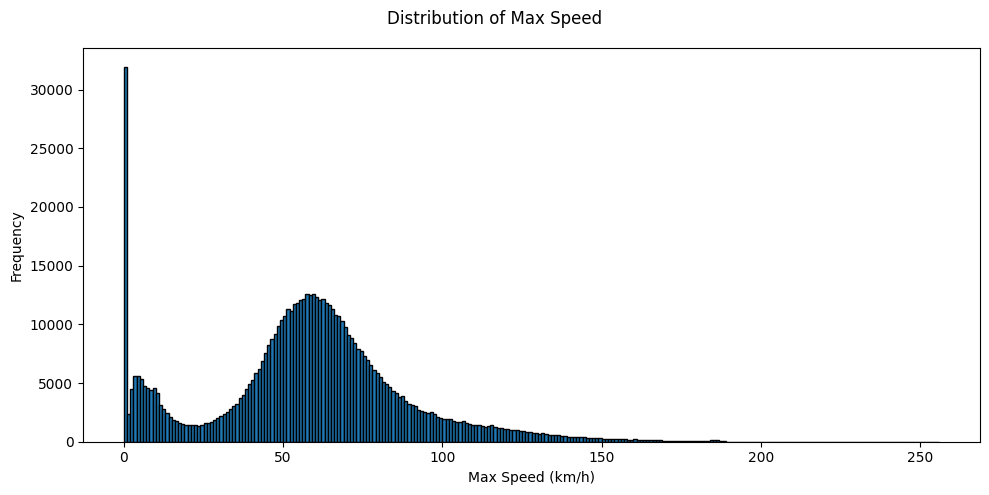

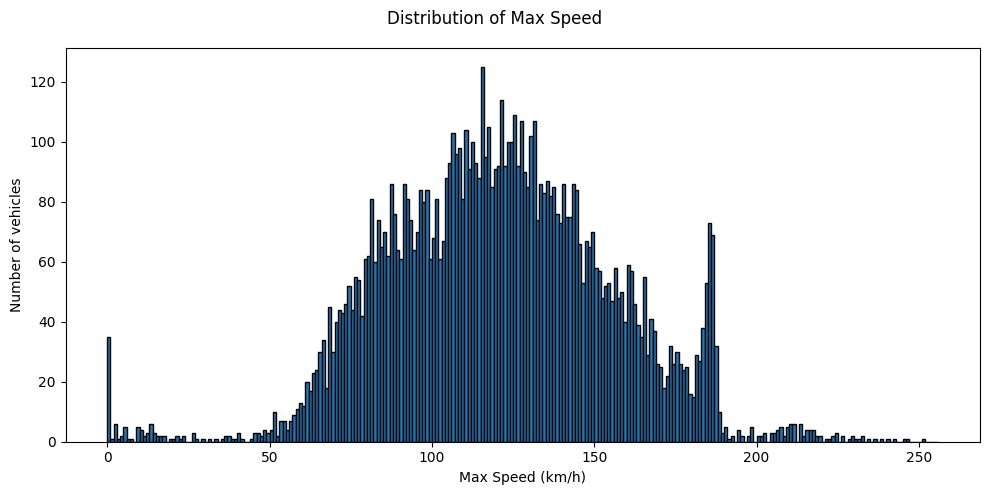

In [0]:
# 描画（最高車速ごとの頻度）
plot_distribution(
    pd_df,                                   # Pandas形式のデータフレーム
    column_name={                            # データのカラム名                     
        "vin": "MASKED_VIN",                   # VINカラム名
    },
    target_col='MAX_SPEED',                  # 集計対象カラム名
    distribution_type="frequency",           # 分布タイプ(頻度:"frequency", 車両数: "number_of_vehicles")
    plt_params={                             # 描画設定
        'figsize': (10, 5),                    # 図のサイズ
        'bin_width': 1,                        # ヒストグラムの幅
        'title': 'Distribution of Max Speed',  # 図のタイトル
        'xlabel': 'Max Speed (km/h)',          # x軸ラベル
        'color': 'C0',                         # カラー
        'xlim': (None, None)                   # x軸の範囲
    }
)

# 描画（最高車速ごとの台数）
plot_distribution(
    pd_df,                                   # Pandas形式のデータフレーム
    column_name={                            # データのカラム名                     
        "vin": "MASKED_VIN",                   # VINカラム名
    },
    target_col='MAX_SPEED',                  # 集計対象カラム名
    distribution_type="number_of_vehicles",  # 分布タイプ(頻度:"frequency", 車両数: "number_of_vehicles")
    plt_params={                             # 描画設定
        'figsize': (10, 5),                    # 図のサイズ
        'bin_width': 1,                        # ヒストグラムの幅
        'title': 'Distribution of Max Speed',  # 図のタイトル
        'xlabel': 'Max Speed (km/h)',          # x軸ラベル
        'color': 'C0',                         # カラー
        'xlim': (None, None)                   # x軸の範囲
    }
)